# 1000 Genomes Project - Full Analysis Pipeline
### chr1 SNVs → PLINK → LD Pruning → PCA → ADMIXTURE


---

### Step 0 - manually download the vcf and vcf index files

### STEP 1 — Install required tools

In [ ]:
# Install system tools in a new env
#i run this in the terminal
"conda create -n genometh_env"
"conda activate genometh_env"
"conda install ipykernel"
"conda install -c conda-forge wget -y"
"conda install -c bioconda admixture -y"

"conda install -c conda-forge pandas matplotlib seaborn -y"


#install PLINK
"conda install -c bioconda plink2"



In [ ]:
#make an output file to store my data
import os
os.chdir("/mnt/c/Users/grgin/Desktop/uzh_masters/BIO392/day10/1/")
!mkdir -p ./output/

### Step 2: run PLINK

PLINK is a free open-source tool widely used in genetics and bioinformatics for analyzing genomic data, particularly SNP (Single Nucleotide Polymorphism) data.PLINK is a free open-source tool widely used in genetics and bioinformatics for analyzing genomic data, particularly SNP (Single Nucleotide Polymorphism) data.


What it does:

- Handles large genomic datasets efficiently
- Quality control filtering of genotype data
- Computes allele frequencies, Hardy-Weinberg statistics
- LD (linkage disequilibrium) pruning
- PCA on genotype data
- Association studies (GWAS)
- File format conversion

In [3]:
#run plink
!plink2 \
  --vcf "/mnt/c/Users/grgin/Desktop/uzh_masters/BIO392/day10/1/ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz" \
  --make-bed \
  --out ./output/chr1_plink \
  --double-id \
  --geno 0.05 \
  --mind 0.05 \
  --hwe 1e-6 \
  --maf 0.01

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ./output/chr1_plink.log.
Options in effect:
  --double-id
  --geno 0.05
  --hwe 1e-6
  --maf 0.01
  --make-bed
  --mind 0.05
  --out ./output/chr1_plink
  --vcf /mnt/c/Users/grgin/Desktop/uzh_masters/BIO392/day10/1/ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz

Start time: Wed Apr 29 10:53:06 2026
7612 MiB RAM detected, ~3970 available; reserving 3806 MiB for main workspace.
Using up to 6 compute threads.
--vcf: 5795045 variants scanned.
--vcf: ./output/chr1_plink-temporary.pgen +
./output/chr1_plink-temporary.pvar.zst + ./output/chr1_plink-temporary.psam
written.
2548 samples (0 females, 0 males, 2548 ambiguous; 2548 founders) loaded from
./output/chr1_plink-temporary.psam.
5795045 variants loaded from ./output/chr1_plink-temporary.pvar.zst.
Note: No phenotype data present.
Calculating sample missingne

---
### STEP 3 — LD Pruning
Removes highly correlated SNPs so that PCA & ADMIXTURE reflect true population structure, not local LD patterns. In other words, ADMIXTURE and PCA assume SNPs are independent — if you include correlated SNPs you violate this assumption and bias your results. Because correlated SNPs are redundant, they carry the same information.


Parameters: window=50 SNPs, step=10, r²<0.1

In [ ]:
#fix names, remove duplicate variant IDs
!plink2 \
  --bfile "./output/chr1_plink" \
  --set-all-var-ids @:#:\$r:\$a \
  --make-bed \
  --out "./output/chr1_plink_fixed"




PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ./output/chr1_plink_fixed.log.
Options in effect:
  --bfile ./output/chr1_plink
  --make-bed
  --out ./output/chr1_plink_fixed
  --set-all-var-ids @:#:$r:$a

Start time: Wed Apr 29 11:14:44 2026
7612 MiB RAM detected, ~4061 available; reserving 3806 MiB for main workspace.
Using up to 6 compute threads.
2548 samples (0 females, 0 males, 2548 ambiguous; 2548 founders) loaded from
./output/chr1_plink.fam.
724345 variants loaded from ./output/chr1_plink.bim.
Note: No phenotype data present.
Writing ./output/chr1_plink_fixed.fam ... done.
Writing ./output/chr1_plink_fixed.bim ... done.
Writing ./output/chr1_plink_fixed.bed ... 18273645546372819099done.
End time: Wed Apr 29 11:15:00 2026


In [ ]:

# Prune LD SNPs
!plink2 \
  --bfile "./output/chr1_plink_fixed" \
  --indep-pairwise 50 10 0.1 \
  --out "./output/chr1_pruned"


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ./output/chr1_pruned.log.
Options in effect:
  --bfile ./output/chr1_plink_fixed
  --indep-pairwise 50 10 0.1
  --out ./output/chr1_pruned

Start time: Wed Apr 29 11:16:02 2026
7612 MiB RAM detected, ~4018 available; reserving 3806 MiB for main workspace.
Using up to 6 compute threads.
2548 samples (0 females, 0 males, 2548 ambiguous; 2548 founders) loaded from
./output/chr1_plink_fixed.fam.
724345 variants loaded from ./output/chr1_plink_fixed.bim.
Note: No phenotype data present.
Calculating allele frequencies... 18273645546372819099done.
--indep-pairwise (1 compute thread): 18273645546372819099607111/724345 variants removed.
Variant lists written to ./output/chr1_pruned.prune.in and
./output/chr1_pruned.prune.out .
End time: Wed Apr 29 11:17:05 2026


In [ ]:
#Extract the pruned SNP
!plink2 \
  --bfile "./output/chr1_plink_fixed" \
  --extract "./output/chr1_pruned.prune.in" \
  --make-bed \
  --out "./output/chr1_pruned_data"

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ./output/chr1_pruned_data.log.
Options in effect:
  --bfile ./output/chr1_plink_fixed
  --extract ./output/chr1_pruned.prune.in
  --make-bed
  --out ./output/chr1_pruned_data

Start time: Wed Apr 29 11:18:03 2026
7612 MiB RAM detected, ~4090 available; reserving 3806 MiB for main workspace.
Using up to 6 compute threads.
2548 samples (0 females, 0 males, 2548 ambiguous; 2548 founders) loaded from
./output/chr1_plink_fixed.fam.
724345 variants loaded from ./output/chr1_plink_fixed.bim.
Note: No phenotype data present.
--extract: 117234 variants remaining.
117234 variants remaining after main filters.
Writing ./output/chr1_pruned_data.fam ... done.
Writing ./output/chr1_pruned_data.bim ... done.
Writing ./output/chr1_pruned_data.bed ... 19283645546472819099done.
End time: Wed Apr 29 11:18:30 2026


In [ ]:
#check variant number before and after the pruning
before = sum(1 for _ in open("./output/chr1_plink_fixed.bim"))
after  = sum(1 for _ in open("./output/chr1_pruned_data.bim"))

print(f"SNPs before pruning: {before:,}")
print(f"SNPs after pruning:  {after:,}")
print(f"SNPs removed:        {before - after:,}")

SNPs before pruning: 724,345
SNPs after pruning:  117,234
SNPs removed:        607,111


About 80% of SNPs were pruned with the thershold of r^2<0.1. 

---

### STEP 6 — PCA (Principal Component Analysis)
In this case each individual is described by thousands of variables (SNPs loci). We can't visualize that in thousands of dimensions. PCA finds a way to summarize them. By definition PCA is a linear dimensionality reduction technique with applications in exploratory data analysis, visualization and data preprocessing.


The variation captured by the first few PCs often corresponds to real biological structure — in your case ancestry. That's why when you plotted PC1 vs PC2 colored by population you saw clean separated clusters — PC1 and PC2 were capturing population differences.

In [15]:
!plink2 \
  --bfile "./output/chr1_pruned_data" \
  --pca 10 \
  --out "./output/chr1_pca"



PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Error: Failed to open ./output/chr1_pca.log for logging: No such file or directory.


### Visualize PCA Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


In [ ]:
os.chdir("/mnt/c/Users/grgin/Desktop/uzh_masters/BIO392/day10/1/")

In [4]:

# Load PCA results
pca = pd.read_csv("./output/chr1_pca.eigenvec", sep=r"\s+", header=None)
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, 11)]

# Load population panel
!wget -c "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel"
panel = pd.read_csv("./integrated_call_samples_v3.20130502.ALL.panel", sep="\t")

# Load eigenvalues
eigenval = pd.read_csv("./output/chr1_pca.eigenval", header=None, names=["val"])
var_exp = (eigenval["val"] / eigenval["val"].sum() * 100).round(1)

# Merge PCA with population labels
df = pca.merge(panel[["sample", "pop", "super_pop"]], left_on="IID", right_on="sample")

# Superpopulation colors
colors = {"AFR": "#E41A1C", "AMR": "#FF7F00", "EAS": "#4DAF4A", "EUR": "#377EB8", "SAS": "#984EA3"}

# Preview
print(df.head())
print(f"\nSamples matched: {len(df)}")

--2026-04-30 16:29:18--  https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel
Resolving ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)... 193.62.193.167
Connecting to ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)|193.62.193.167|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

       FID      IID         PC1        PC2           PC3        PC4  \
0  HG00096  HG00096  -0.0135267  0.0250413   -0.00244698  0.0224279   
1  HG00097  HG00097  -0.0126724  0.0262398  -0.000760991   0.022613   
2  HG00099  HG00099  -0.0131968  0.0260223   -0.00106926  0.0210749   
3  HG00100  HG00100  -0.0130201  0.0266821    -0.0013265  0.0199075   
4  HG00101  HG00101  -0.0135422  0.0259308   -0.00200219  0.0206517   

            PC5           PC6          PC7         PC8         PC9  \
0    0.00107121   -0.00325853   -0.0125564  -0.0106682

In [5]:
# Convert all PC columns to numeric
for i in range(1, 11):
    df[f"PC{i}"] = pd.to_numeric(df[f"PC{i}"], errors="coerce")

# Check it worked
print(df["PC1"].describe())
print(df["PC2"].describe())

count    2503.000000
mean        0.000030
std         0.019832
min        -0.014632
25%        -0.012599
50%        -0.011493
75%         0.022315
max         0.037499
Name: PC1, dtype: float64
count    2503.000000
mean       -0.000029
std         0.019781
min        -0.037917
25%        -0.001817
50%         0.001415
75%         0.013651
max         0.028290
Name: PC2, dtype: float64


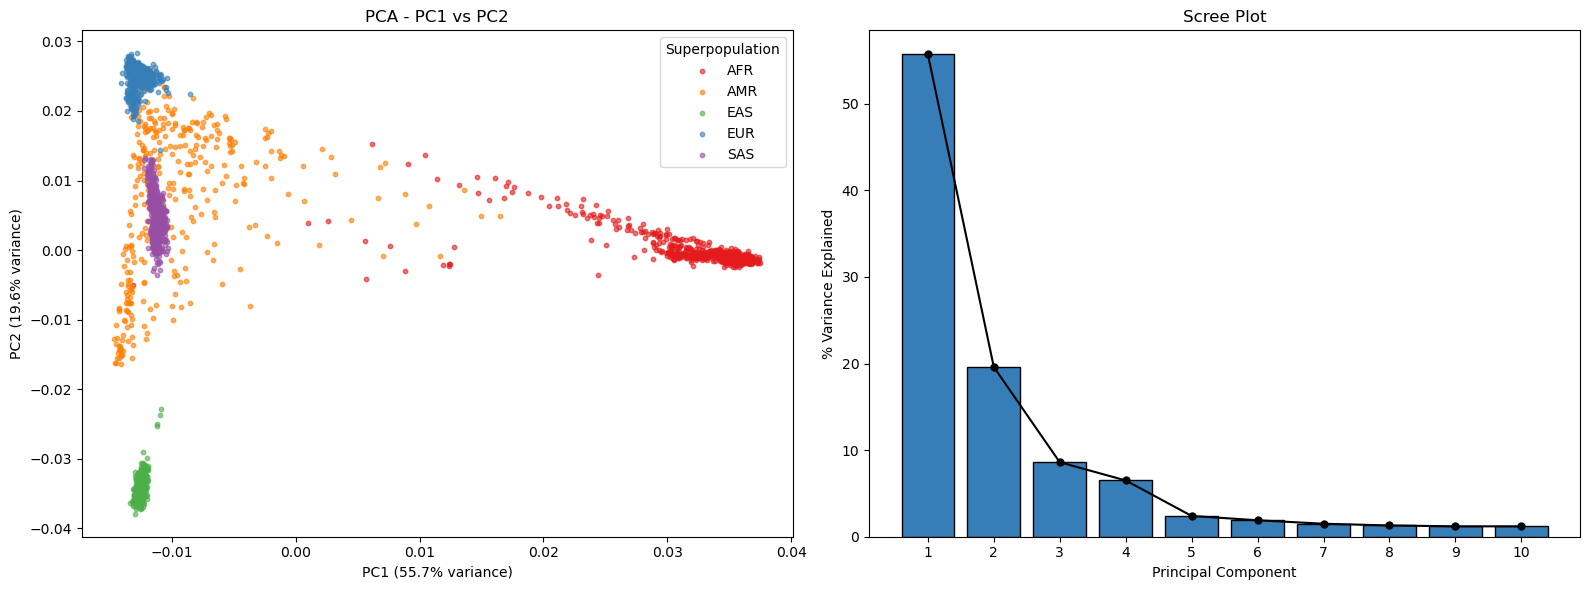

Saved: plot_PCA.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: PC1 vs PC2 ---
for spop, grp in df.groupby("super_pop"):
    axes[0].scatter(grp["PC1"], grp["PC2"], 
                    c=colors[spop], label=spop, alpha=0.6, s=10)

axes[0].set_xlabel(f"PC1 ({var_exp[0]}% variance)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]}% variance)")
axes[0].set_title("PCA - PC1 vs PC2")
axes[0].legend(title="Superpopulation")

# --- Plot 2: Scree plot ---
axes[1].bar(range(1, 11), var_exp, color="#377EB8", edgecolor="black")
axes[1].plot(range(1, 11), var_exp, "ko-", markersize=5)
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("% Variance Explained")
axes[1].set_title("Scree Plot")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig("./output/plot_PCA.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_PCA.png")

### STEP 8 — ADMIXTURE Analysis (K = 5)
ADMIXTURE is a tool that estimates ancestry proportions for each individual assuming the population is made up of K ancestral groups.

Because the 1000 Genomes Project has samples from 5 major continental superpopulations, I opted for K=5.

This took aout 30 mins, if I had more time I would have tried different K-s.

In [ ]:
#i had some problems,i run im the terminal

"./admixture ./output/chr1_pruned_data.bed 5"

### STEP 9 — Visualize ADMIXTURE Results

In [7]:
# Clean up panel
panel = panel[["sample", "super_pop"]].dropna()
panel = panel.set_index("sample")

In [8]:
# Load fam file to get sample order (same order as Q file)
fam = pd.read_csv("output/chr1_pruned_data.fam", sep="\t", header=None)
sample_order = fam[1].values

# Load Q file
Q = pd.read_csv("chr1_pruned_data.5.Q", sep=" ", header=None)
Q.columns = [f"Pop{i+1}" for i in range(5)]
Q.index = sample_order


In [ ]:
# Check if samples in Q and panel dataset match
common = Q.index.intersection(panel.index)
print(f"Samples in Q: {len(Q)}")
print(f"Samples in panel: {len(panel)}")
print(f"Common samples: {len(common)}")

# Keep only common samples
Q = Q.loc[common]
Q["Superpopulation"] = panel.loc[common, "super_pop"].values

# Sort by superpopulation
Q = Q.sort_values("Superpopulation")
superpop = Q.pop("Superpopulation")

Samples in Q: 2548
Samples in panel: 2504
Common samples: 2503


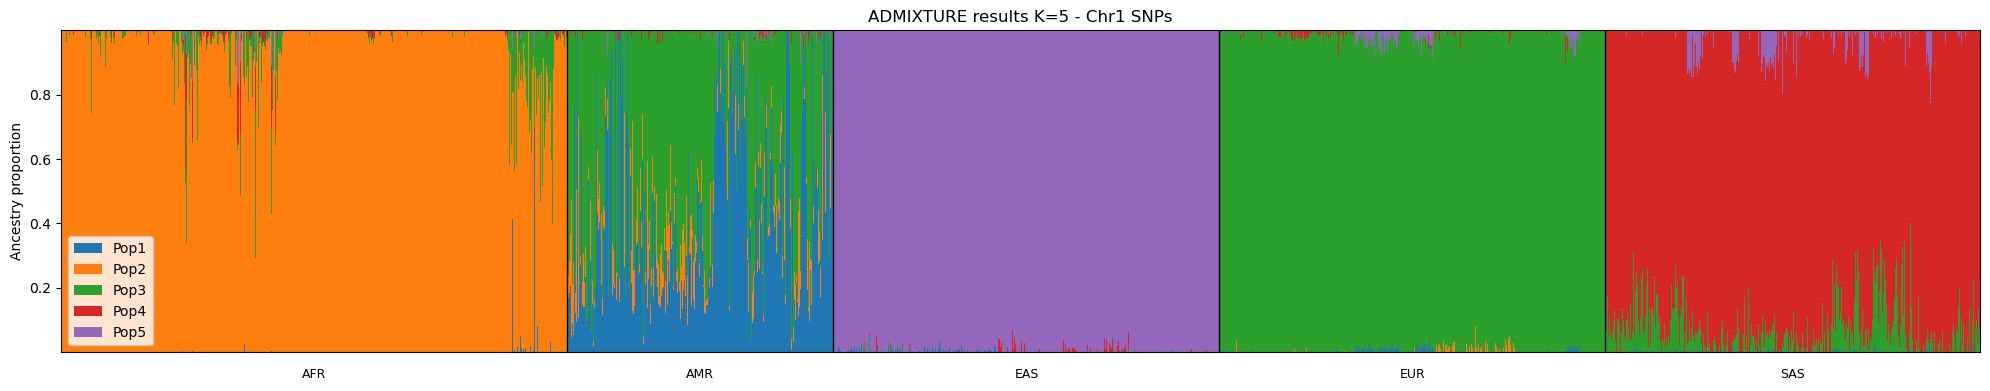

In [11]:
# Plot
fig, ax = plt.subplots(figsize=(20, 4))
Q.plot(kind="bar", stacked=True, ax=ax, width=1.0)

ax.set_xticks([])
ax.set_ylabel("Ancestry proportion")
ax.set_title("ADMIXTURE results K=5 - Chr1 SNPs")

# Population boundary lines and labels
boundaries = np.where(superpop.values[:-1] != superpop.values[1:])[0]
for b in boundaries:
    ax.axvline(x=b, color="black", linewidth=1)

prev = 0
for b in np.append(boundaries, len(superpop)-1):
    mid = (prev + b) / 2
    ax.text(mid, -0.08, superpop.values[prev],
            ha="center", fontsize=9, transform=ax.get_xaxis_transform())
    prev = b + 1

plt.tight_layout()
plt.show()

The ADMIXTURE model with 5 Ks clearly identified 5 continental populations with the given SNP data. The color distirbution between continent sections correspond to the color distributions and overlaps seen in the PCA. The most overlapped regions would be the Americans while Africans and East Asians seem to have the most distinctive SNP patterns with this K number. This would be expected as it reflects human evolution histroy and migrations - all modern humans originated from Africa.